In [27]:
%pip install ortools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from ortools.sat.python import cp_model
from random import randint
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (40,15)

# Data

In [29]:
n_hospitales = 5
n_pacientes = 500
n_camas_en_hospitales = [randint(10,100) for _ in range(n_hospitales)]
print(n_camas_en_hospitales)
n_camas_total = sum(n_camas_en_hospitales)
print(n_camas_total)

#localización
pacientes_loc = [(randint(0,100),randint(0,100)) for _ in range(n_pacientes)]
print(pacientes_loc)
hospitales_loc = [(randint(0,100),randint(0,100)) for _ in range(n_hospitales)]
print(hospitales_loc)
#grado de contagio
pacientes_contagio = [randint(1,5) for _ in range(n_pacientes)]
print(pacientes_contagio)

[58, 86, 69, 77, 42]
332
[(70, 1), (87, 92), (14, 87), (68, 96), (34, 98), (82, 43), (14, 37), (55, 20), (58, 0), (92, 92), (33, 64), (97, 22), (64, 13), (80, 38), (81, 64), (77, 25), (19, 47), (97, 20), (69, 99), (67, 0), (76, 41), (62, 2), (14, 46), (39, 30), (7, 30), (72, 10), (10, 93), (62, 8), (97, 68), (98, 16), (16, 84), (60, 70), (21, 33), (67, 77), (54, 27), (69, 96), (93, 88), (25, 91), (39, 51), (85, 83), (47, 56), (66, 57), (15, 31), (28, 8), (43, 2), (75, 70), (29, 75), (28, 0), (9, 90), (80, 7), (29, 8), (4, 42), (9, 65), (30, 35), (85, 62), (27, 69), (16, 92), (73, 73), (60, 31), (100, 60), (52, 24), (12, 12), (84, 55), (45, 54), (52, 59), (93, 6), (86, 83), (82, 12), (7, 51), (93, 43), (13, 31), (24, 24), (68, 57), (17, 54), (23, 35), (59, 31), (9, 56), (70, 12), (6, 83), (69, 1), (11, 96), (30, 21), (52, 62), (61, 27), (51, 7), (21, 48), (0, 49), (33, 100), (100, 58), (36, 54), (89, 93), (100, 71), (84, 91), (62, 19), (24, 37), (27, 7), (74, 94), (69, 7), (95, 40), (7,

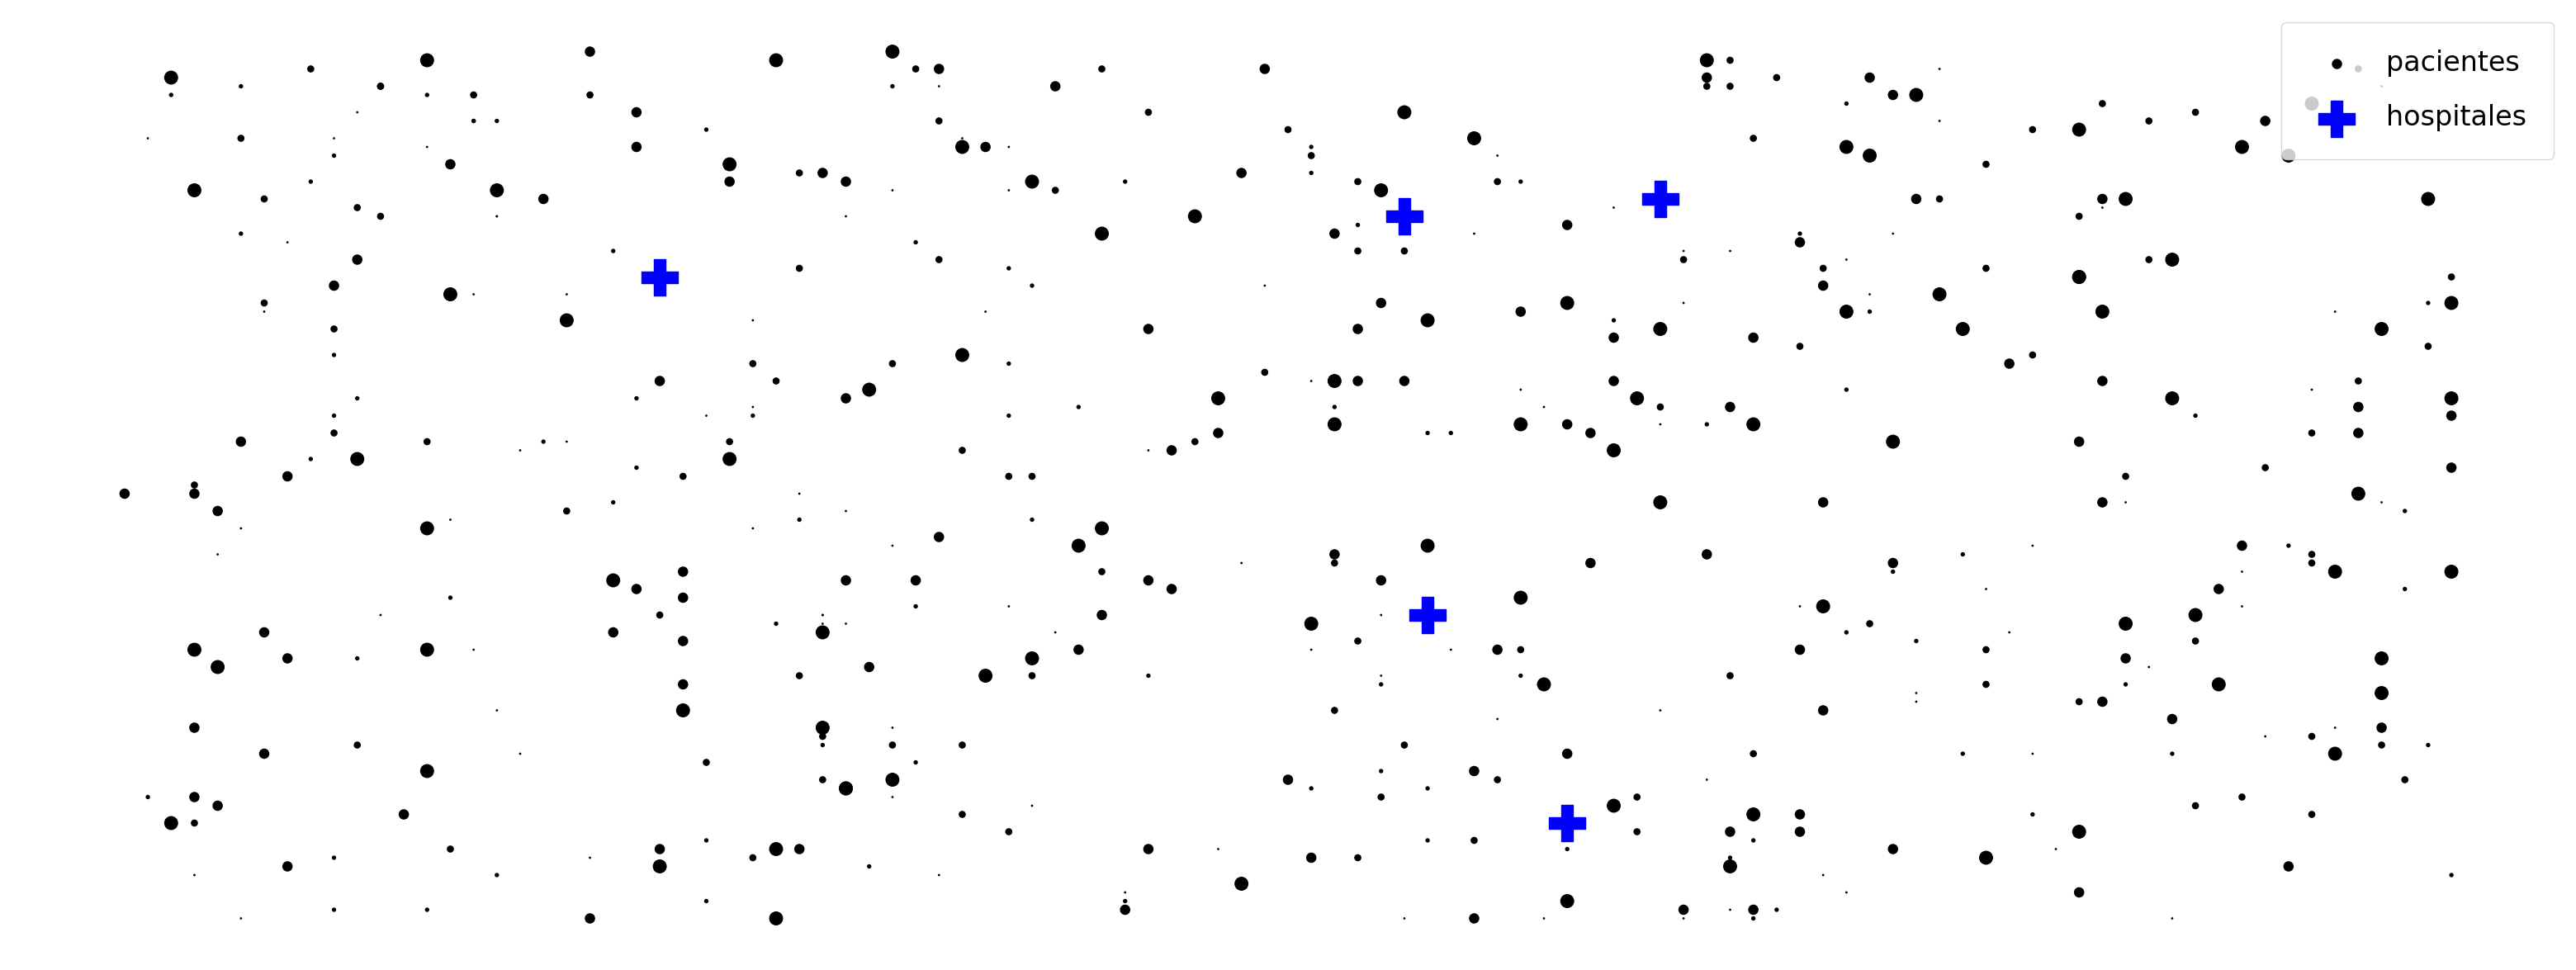

In [30]:
#visualización
tamano_contagio = [sev**3 for sev in pacientes_contagio]
plt.scatter(*zip(*pacientes_loc), s=tamano_contagio, c='black', label='pacientes')
plt.scatter(*zip(*hospitales_loc), s=1000, c='b', marker='P', label='hospitales')
plt.legend(
    fontsize=24, 
    borderpad=1,
    labelspacing =1,
    loc = 'upper right'
)
plt.axis('off')
plt.show()

# CSP

In [31]:
#crear CSP
model = cp_model.CpModel()

#variables y dominios
x = {}
for i in range(n_hospitales):
  for j in range(n_camas_en_hospitales[i]):
    for k in range(n_pacientes):
      x[(i,j,k)] = model.NewBoolVar('x_'+str(i)+'_'+str(j)+'_'+str(k))

#restricciones
##hard constraints
##There must be at most a single person in every bed.
for i in range(n_hospitales): #para cada hospital
  for j in range(n_camas_en_hospitales[i]): #para cada cama del hospital i
    model.Add(sum([x[(i,j,k)] for k in range(n_pacientes)]) <= 1)
##There must be at most a single bed assigned to every person.
for k in range(n_pacientes): #para cada paciente
  n_pacientes_camas_hospitales = []
  for i in range(n_hospitales): #para cada hospital
    n_pacientes_camas_hospitales.append(sum(x[(i,j,k)] for j in range(n_camas_en_hospitales[i]))) #sumar para todas las camas, las que tengan al paciente k
  model.Add(sum(n_pacientes_camas_hospitales) <= 1)

def dist(p1,p2):
  return int(((p1[0]-p2[0])**2+(p1[1]-p2[1])**2)**0.5)

max_dist = 0
for i in range(n_hospitales):
  for k in range(n_pacientes):
    if max_dist < dist(hospitales_loc[i], pacientes_loc[k]):
      max_dist = dist(hospitales_loc[i], pacientes_loc[k])

##soft constraints
pref = []
for i in range(n_hospitales):
  for j in range(n_camas_en_hospitales[i]):
    for k in range(n_pacientes):
      #Every sick person should be placed into a bed
      #Every person should be handled by the nearest hospital
      #Sick persons in severe condition should be handled first when there are not enough beds.
      #pref += [x[(i,j,k)] - x[(i,j,k)] * dist(pacientes_loc[k], hospitales_loc[i]) + x[(i,j,k)] * pacientes_contagio[k]]
      pref += [x[(i,j,k)] * (100 - 100 * dist(pacientes_loc[k], hospitales_loc[i]) / max_dist + 100 * pacientes_contagio[k] / 5)]
#print(pref)
model.Maximize(sum(pref))

In [32]:
#solver
solver = cp_model.CpSolver()
status = solver.Solve(model)
if status == cp_model.OPTIMAL:
  print('Tiempo:',solver.WallTime())
  for i in range(n_hospitales):
    print('Hospital {} {} tiene {} camas'.format(i+1,hospitales_loc[i],n_camas_en_hospitales[i]))
    for j in range(n_camas_en_hospitales[i]):
      for k in range(n_pacientes):
        if solver.Value(x[(i,j,k)]):
          print('\tPaciente {} en la cama {}'.format(k+1,j+1))
    print()

Tiempo: 370.6077045
Hospital 1 (66, 83) tiene 58 camas
	Paciente 370 en la cama 1
	Paciente 343 en la cama 2
	Paciente 295 en la cama 3
	Paciente 300 en la cama 4
	Paciente 2 en la cama 5
	Paciente 268 en la cama 6
	Paciente 495 en la cama 7
	Paciente 10 en la cama 8
	Paciente 155 en la cama 9
	Paciente 396 en la cama 10
	Paciente 257 en la cama 11
	Paciente 15 en la cama 12
	Paciente 240 en la cama 13
	Paciente 465 en la cama 14
	Paciente 113 en la cama 15
	Paciente 136 en la cama 16
	Paciente 441 en la cama 17
	Paciente 97 en la cama 18
	Paciente 67 en la cama 19
	Paciente 402 en la cama 20
	Paciente 312 en la cama 21
	Paciente 60 en la cama 22
	Paciente 134 en la cama 23
	Paciente 92 en la cama 24
	Paciente 192 en la cama 25
	Paciente 231 en la cama 26
	Paciente 232 en la cama 27
	Paciente 446 en la cama 28
	Paciente 58 en la cama 29
	Paciente 454 en la cama 30
	Paciente 40 en la cama 31
	Paciente 178 en la cama 32
	Paciente 29 en la cama 33
	Paciente 277 en la cama 34
	Paciente 431

In [33]:
plot_lineas = [[] for _ in range(n_hospitales)]
for i in range(n_hospitales):
  for j in range(n_camas_en_hospitales[i]):
    for k in range(n_pacientes):
      if solver.Value(x[(i,j,k)]):
        linea_abcisa = [hospitales_loc[i][0], pacientes_loc[k][0]]
        linea_ordenada = [hospitales_loc[i][1], pacientes_loc[k][1]]
        plot_lineas[i].append([linea_abcisa,linea_ordenada])

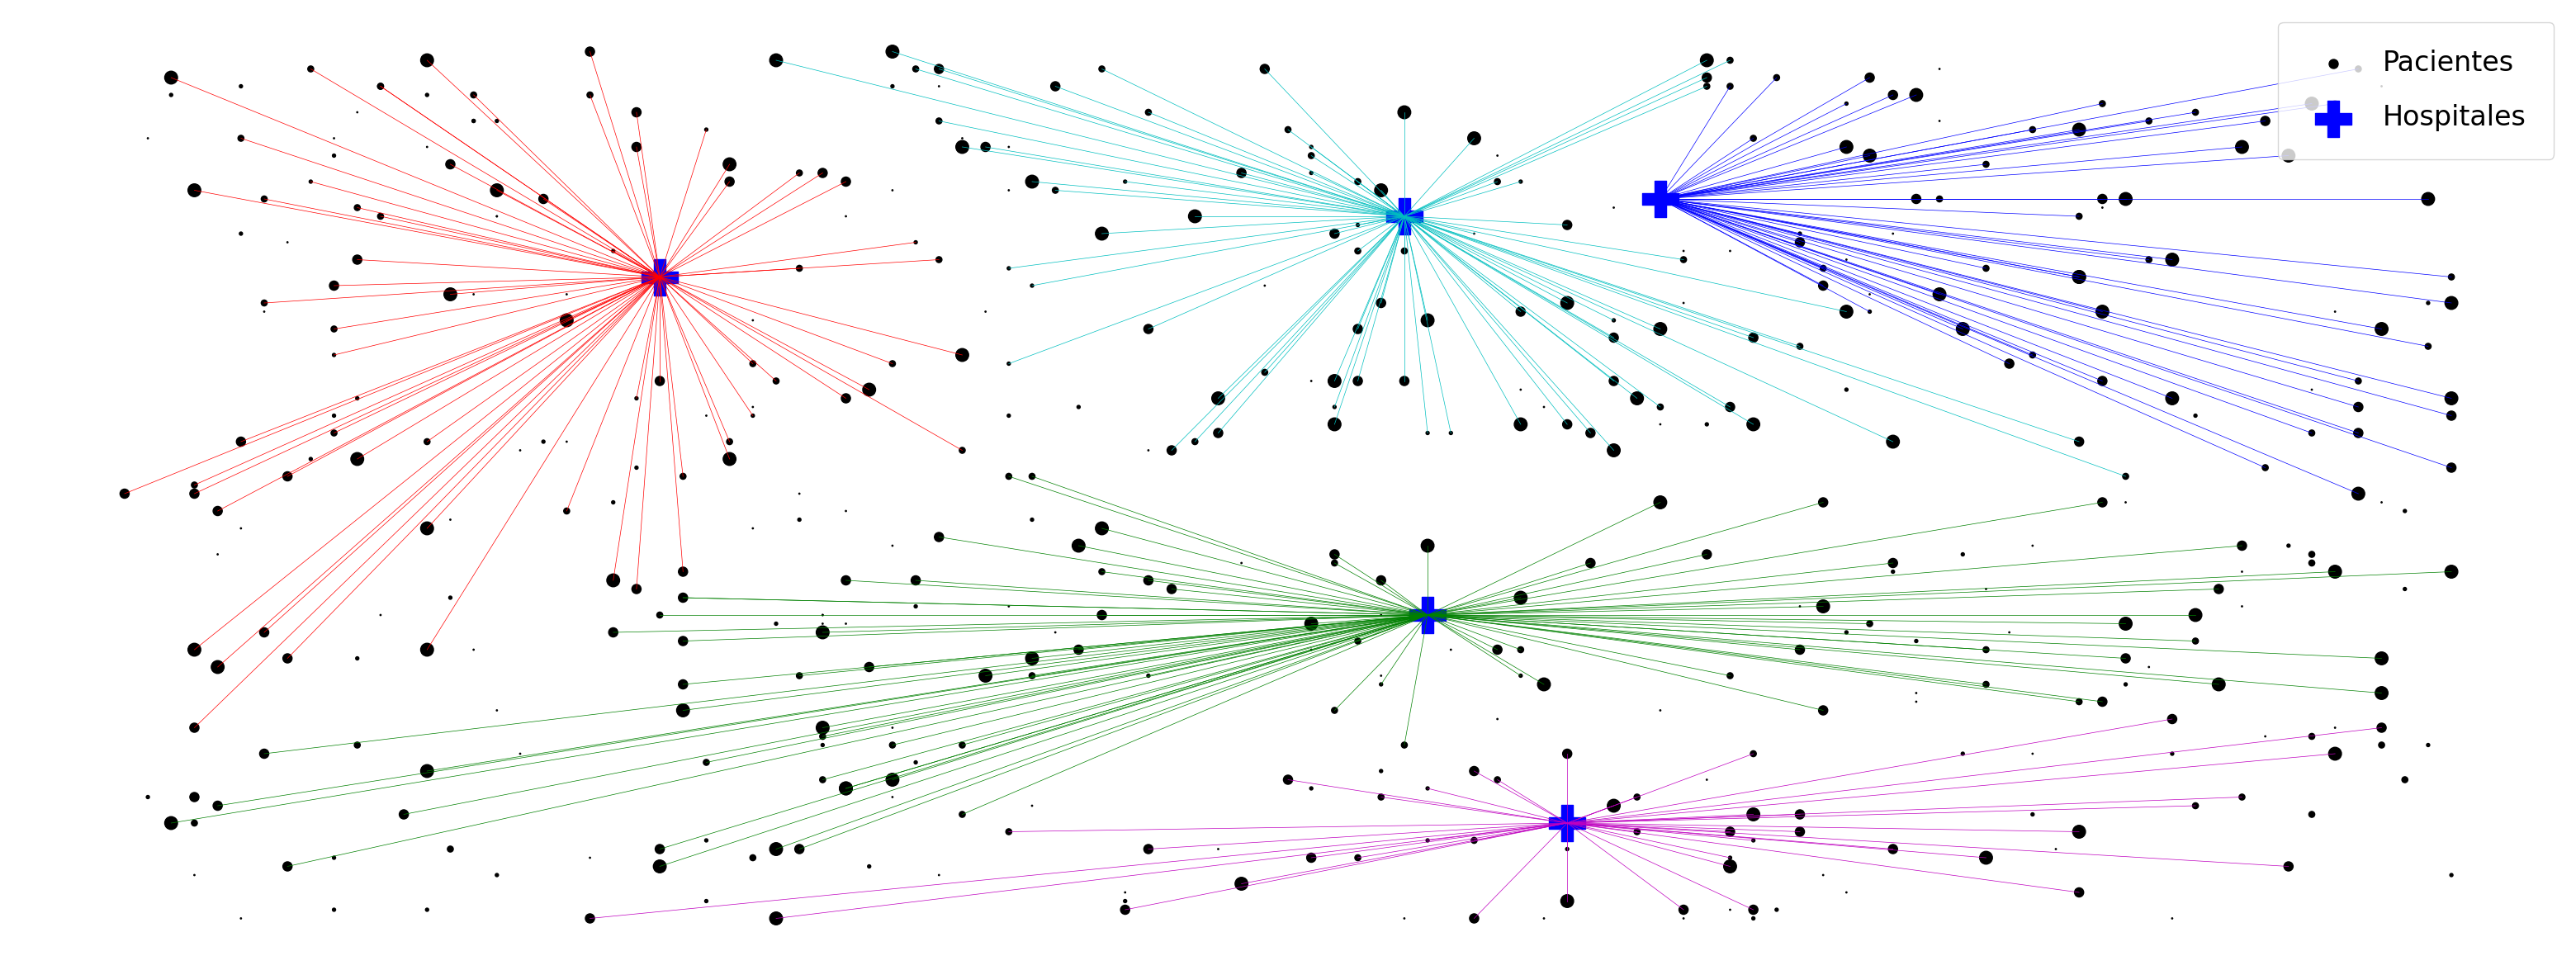

In [34]:
from itertools import cycle

plt.scatter(*zip(*pacientes_loc), s=tamano_contagio, color='black', label='Pacientes')
plt.scatter(*zip(*hospitales_loc), s=1000, color='blue', marker='P', label='Hospitales')
#plotear líneas de hospitales por colores
colores = cycle('bgrcmk')
for i in range(n_hospitales):
  c = next(colores)
  for (x_,y_) in plot_lineas[i]:
    plt.plot(x_, y_, c=c, linewidth=.5)
plt.legend(
    fontsize=24, 
    borderpad=1,
    labelspacing =1,
    loc = 'upper right'
)
plt.axis('off')
plt.show()

In [35]:
import random
random.seed(42)

MAX_NIVEL1_POR_HOSPITAL = 20  # Restriccion: maximo 20 pacientes nivel-1 por hospital
RADIO_PROXIMIDAD = 15         # Radio en unidades del mapa para detectar pacientes nivel-5 cerca de nivel-1
BONUS_PRIORIDAD = 50          # Bonus extra de preferencia para nivel-5 en zona de riesgo

puede_moverse = []
for k in range(n_pacientes):
    if pacientes_contagio[k] == 5:
        puede_moverse.append(random.random() < 0.5)  # 50% de probabilidad
    else:
        puede_moverse.append(True)  # Los demas siempre pueden moverse

n_nivel5_puede    = sum(1 for k in range(n_pacientes) if pacientes_contagio[k] == 5 and     puede_moverse[k])
n_nivel5_no_puede = sum(1 for k in range(n_pacientes) if pacientes_contagio[k] == 5 and not puede_moverse[k])
print('Pacientes nivel-5 que PUEDEN moverse al hospital:', n_nivel5_puede)
print('Pacientes nivel-5 que NO pueden moverse al hospital:', n_nivel5_no_puede)

Pacientes nivel-5 que PUEDEN moverse al hospital: 49
Pacientes nivel-5 que NO pueden moverse al hospital: 46


In [36]:
paciente_en_zona_riesgo = [False] * n_pacientes

for k in range(n_pacientes):
    if pacientes_contagio[k] == 5 and puede_moverse[k]:
        for k2 in range(n_pacientes):
            if pacientes_contagio[k2] == 1:
                if dist(pacientes_loc[k], pacientes_loc[k2]) <= RADIO_PROXIMIDAD:
                    paciente_en_zona_riesgo[k] = True
                    break

n_zona_riesgo = sum(paciente_en_zona_riesgo)
print('Pacientes nivel-5 en zona de riesgo (cerca de nivel-1):', n_zona_riesgo)

Pacientes nivel-5 en zona de riesgo (cerca de nivel-1): 49


In [37]:
model2 = cp_model.CpModel()

x2 = {}
for i in range(n_hospitales):
    for j in range(n_camas_en_hospitales[i]):
        for k in range(n_pacientes):
            if puede_moverse[k]:
                x2[(i,j,k)] = model2.NewBoolVar('x2_'+str(i)+'_'+str(j)+'_'+str(k))

for i in range(n_hospitales):
    for j in range(n_camas_en_hospitales[i]):
        model2.Add(sum(x2[(i,j,k)] for k in range(n_pacientes) if puede_moverse[k]) <= 1)

for k in range(n_pacientes):
    if puede_moverse[k]:
        total_camas_k = []
        for i in range(n_hospitales):
            total_camas_k.append(sum(x2[(i,j,k)] for j in range(n_camas_en_hospitales[i])))
        model2.Add(sum(total_camas_k) <= 1)

for i in range(n_hospitales):
    pacientes_nivel1_en_hospital = []
    for k in range(n_pacientes):
        if pacientes_contagio[k] == 1 and puede_moverse[k]:
            for j in range(n_camas_en_hospitales[i]):
                pacientes_nivel1_en_hospital.append(x2[(i,j,k)])
    if pacientes_nivel1_en_hospital:
        model2.Add(sum(pacientes_nivel1_en_hospital) <= MAX_NIVEL1_POR_HOSPITAL)

pref2 = []
for i in range(n_hospitales):
    for j in range(n_camas_en_hospitales[i]):
        for k in range(n_pacientes):
            if puede_moverse[k]:
                base_score = int(
                    100
                    - 100 * dist(pacientes_loc[k], hospitales_loc[i]) / max_dist
                    + 100 * pacientes_contagio[k] / 5
                )
                bonus_zona = BONUS_PRIORIDAD if paciente_en_zona_riesgo[k] else 0
                total_score = base_score + bonus_zona
                pref2.append(x2[(i,j,k)] * total_score)

model2.Maximize(sum(pref2))

print('')
print('Restriccion MAX nivel-1 por hospital:', MAX_NIVEL1_POR_HOSPITAL)
print('Radio de proximidad para zona de riesgo:', RADIO_PROXIMIDAD, 'unidades')
print('Bonus de prioridad para nivel-5 en zona de riesgo: +', BONUS_PRIORIDAD, 'puntos')


Restriccion MAX nivel-1 por hospital: 20
Radio de proximidad para zona de riesgo: 15 unidades
Bonus de prioridad para nivel-5 en zona de riesgo: + 50 puntos


In [38]:
solver2 = cp_model.CpSolver()
solver2.parameters.max_time_in_seconds = 60
status2 = solver2.Solve(model2)

if status2 in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    estado_str = 'OPTIMA' if status2 == cp_model.OPTIMAL else 'FACTIBLE (no optima)'
    print('Solucion', estado_str, 'encontrada en', round(solver2.WallTime(), 2), 's')
    total_asignados = 0
    total_nivel1 = [0] * n_hospitales
    total_nivel5_zona_riesgo_asignados = 0
    for i in range(n_hospitales):
        print('')
        print('Hospital', i+1, hospitales_loc[i], '(', n_camas_en_hospitales[i], 'camas):')
        count_h = 0
        for j in range(n_camas_en_hospitales[i]):
            for k in range(n_pacientes):
                if puede_moverse[k] and solver2.Value(x2[(i,j,k)]):
                    nivel = pacientes_contagio[k]
                    zona = ' [ZONA RIESGO]' if paciente_en_zona_riesgo[k] else ''
                    print('  Cama', j+1, ': Paciente', k+1, '(nivel', str(nivel) + ')' + zona)
                    count_h += 1
                    total_asignados += 1
                    if nivel == 1:
                        total_nivel1[i] += 1
                    if paciente_en_zona_riesgo[k]:
                        total_nivel5_zona_riesgo_asignados += 1
        print('  ->', count_h, 'pacientes asignados |', total_nivel1[i], 'de nivel-1 (max', str(MAX_NIVEL1_POR_HOSPITAL) + ')')
    print('')
    print('RESUMEN:')
    print('  Total pacientes asignados:', total_asignados)
    print('  Pacientes nivel-5 en zona de riesgo asignados:', str(total_nivel5_zona_riesgo_asignados) + '/' + str(n_zona_riesgo))
    print('  Pacientes nivel-5 que no pudieron moverse (excluidos):', n_nivel5_no_puede)
else:
    print('No se encontro solucion.')


Solucion FACTIBLE (no optima) encontrada en 62.14 s

Hospital 1 (66, 83) ( 58 camas):
  Cama 1 : Paciente 156 (nivel 3)
  Cama 2 : Paciente 1 (nivel 4)
  Cama 3 : Paciente 2 (nivel 3)
  Cama 4 : Paciente 3 (nivel 4)
  Cama 5 : Paciente 4 (nivel 3)
  Cama 6 : Paciente 5 (nivel 3)
  Cama 7 : Paciente 6 (nivel 1)
  Cama 8 : Paciente 7 (nivel 2)
  Cama 9 : Paciente 8 (nivel 3)
  Cama 10 : Paciente 9 (nivel 4)
  Cama 11 : Paciente 10 (nivel 4)
  Cama 12 : Paciente 11 (nivel 3)
  Cama 13 : Paciente 12 (nivel 4)
  Cama 14 : Paciente 14 (nivel 1)
  Cama 15 : Paciente 15 (nivel 4)
  Cama 16 : Paciente 16 (nivel 1)
  Cama 17 : Paciente 17 (nivel 3)
  Cama 18 : Paciente 18 (nivel 3)
  Cama 19 : Paciente 19 (nivel 3)
  Cama 20 : Paciente 20 (nivel 1)
  Cama 21 : Paciente 21 (nivel 4)
  Cama 22 : Paciente 22 (nivel 5) [ZONA RIESGO]
  Cama 23 : Paciente 23 (nivel 1)
  Cama 24 : Paciente 24 (nivel 5) [ZONA RIESGO]
  Cama 25 : Paciente 25 (nivel 4)
  Cama 26 : Paciente 26 (nivel 4)
  Cama 27 : Pacient

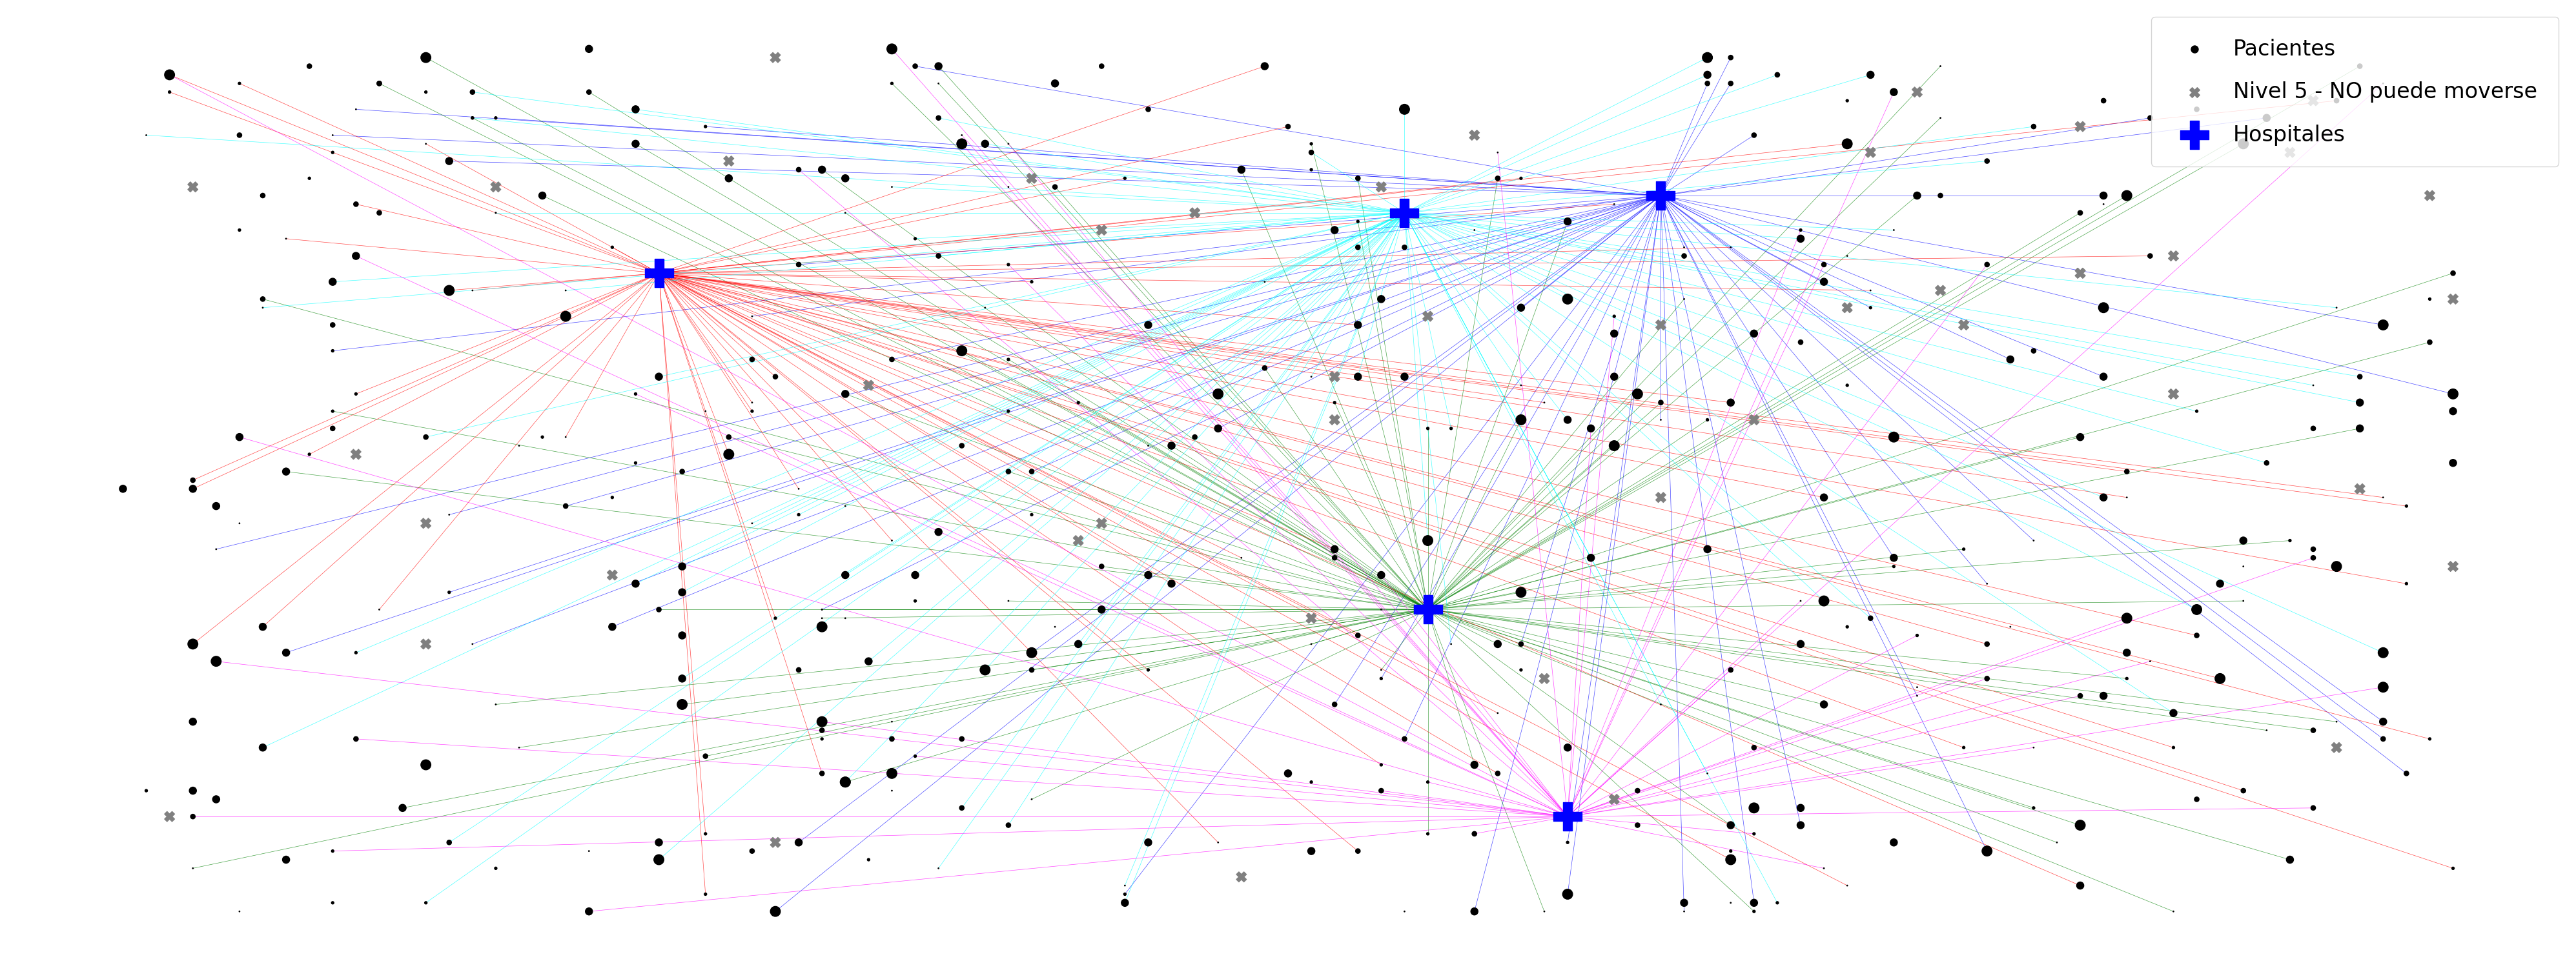

In [39]:
from itertools import cycle

if status2 in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    plot_lineas2 = [[] for _ in range(n_hospitales)]
    for i in range(n_hospitales):
        for j in range(n_camas_en_hospitales[i]):
            for k in range(n_pacientes):
                if puede_moverse[k] and solver2.Value(x2[(i,j,k)]):
                    plot_lineas2[i].append([
                        [hospitales_loc[i][0], pacientes_loc[k][0]],
                        [hospitales_loc[i][1], pacientes_loc[k][1]]
                    ])

    fig, ax = plt.subplots(figsize=(40, 15))

    locs_movil = [pacientes_loc[k] for k in range(n_pacientes) if puede_moverse[k]]
    sizes_movil = [tamano_contagio[k] for k in range(n_pacientes) if puede_moverse[k]]
    if locs_movil:
        ax.scatter(*zip(*locs_movil), s=sizes_movil, color='black', label='Pacientes', zorder=3)

    locs_inmovil = [pacientes_loc[k] for k in range(n_pacientes)
                    if pacientes_contagio[k] == 5 and not puede_moverse[k]]
    sizes_inmovil = [tamano_contagio[k] for k in range(n_pacientes)
                     if pacientes_contagio[k] == 5 and not puede_moverse[k]]
    if locs_inmovil:
        ax.scatter(*zip(*locs_inmovil), s=sizes_inmovil, color='gray', marker='X',
                   label='Nivel 5 - NO puede moverse', zorder=3)

    ax.scatter(*zip(*hospitales_loc), s=1000, color='blue', marker='P', label='Hospitales', zorder=6)

    colores2 = cycle(['blue', 'green', 'red', 'cyan', 'magenta', 'black'])
    for i in range(n_hospitales):
        c = next(colores2)
        for (x_, y_) in plot_lineas2[i]:
            ax.plot(x_, y_, c=c, linewidth=0.5, alpha=0.7)

    ax.legend(fontsize=24, borderpad=1, labelspacing=1, loc='upper right')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No hay solucion para graficar.')
